# ADEPT Sensitivity Analysis: Federated Learning System

This notebook exercises the ADEPT framework's real analysis methodology end to
end against the Federated Learning example: model summary (R4), an explicit
spec-linting sanity check (R1-R3), tradeoff definition, per-decision
contingency analysis for FL's 3 composed pattern decisions, key-parameter
selection via smart correlation with FL's policy-bound pattern parameters
included (R6), PRIM/CART scenario discovery (R9), and box-diagnostics
visualization including a best-effort search for an optional parameter's
"not selected" N/A-hatching state (R10).

It retires `federatedlearning/test_manual_simple.py`,
`federatedlearning/test_nan_feature.ipynb`, and root `test_nan_manual.py` as
the primary validation path (R11); those files remain in place, unmodified.

In [1]:
# Set project root in path so we can import 'adept' package
import sys
sys.path.append("..")

import itertools
import json
import pandas as pd
import matplotlib.pyplot as plt

from adept import PatternAnalysis
from adept.utils.linter import SystemLinter
from adept.utils.spec_summary import summarize_system

# No preprocessor is needed: FLsystem_split.json declares how the per-client columns
# ("Client <N> <field>") are aggregated into system-level parameters and objectives
# (dataspace.aggregations, see adept/utils/aggregation.py).

## 1. Load System & Model Summary (R4)

We initialize a `PatternAnalysis` session against FL's declarative system
definition and load the FL dataset. The spec declares how the 5 clients'
per-client columns are aggregated into system-level parameters and objectives
(`dataspace.aggregations`), so no preprocessor hook is needed. We then print the auto-generated model summary (`summarize_system`,
R4/U2) so the system's decisions, policies, parameter bindings, and
configuration coverage are visible before any analysis is built on top of it.

In [2]:
session = PatternAnalysis('./FLsystem_split.json')
session.load()

print(f"Loaded {len(session.raw_df)} experiments.")
print()
print(summarize_system(session.sys_def))

Loading single source file: ./FLwithAP_MLdata_split.csv
Loaded 32 rows.
[WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
[WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 78.1% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'Total Clients' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING] System.Components: Parameter 'Dataset' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
[WARNING]

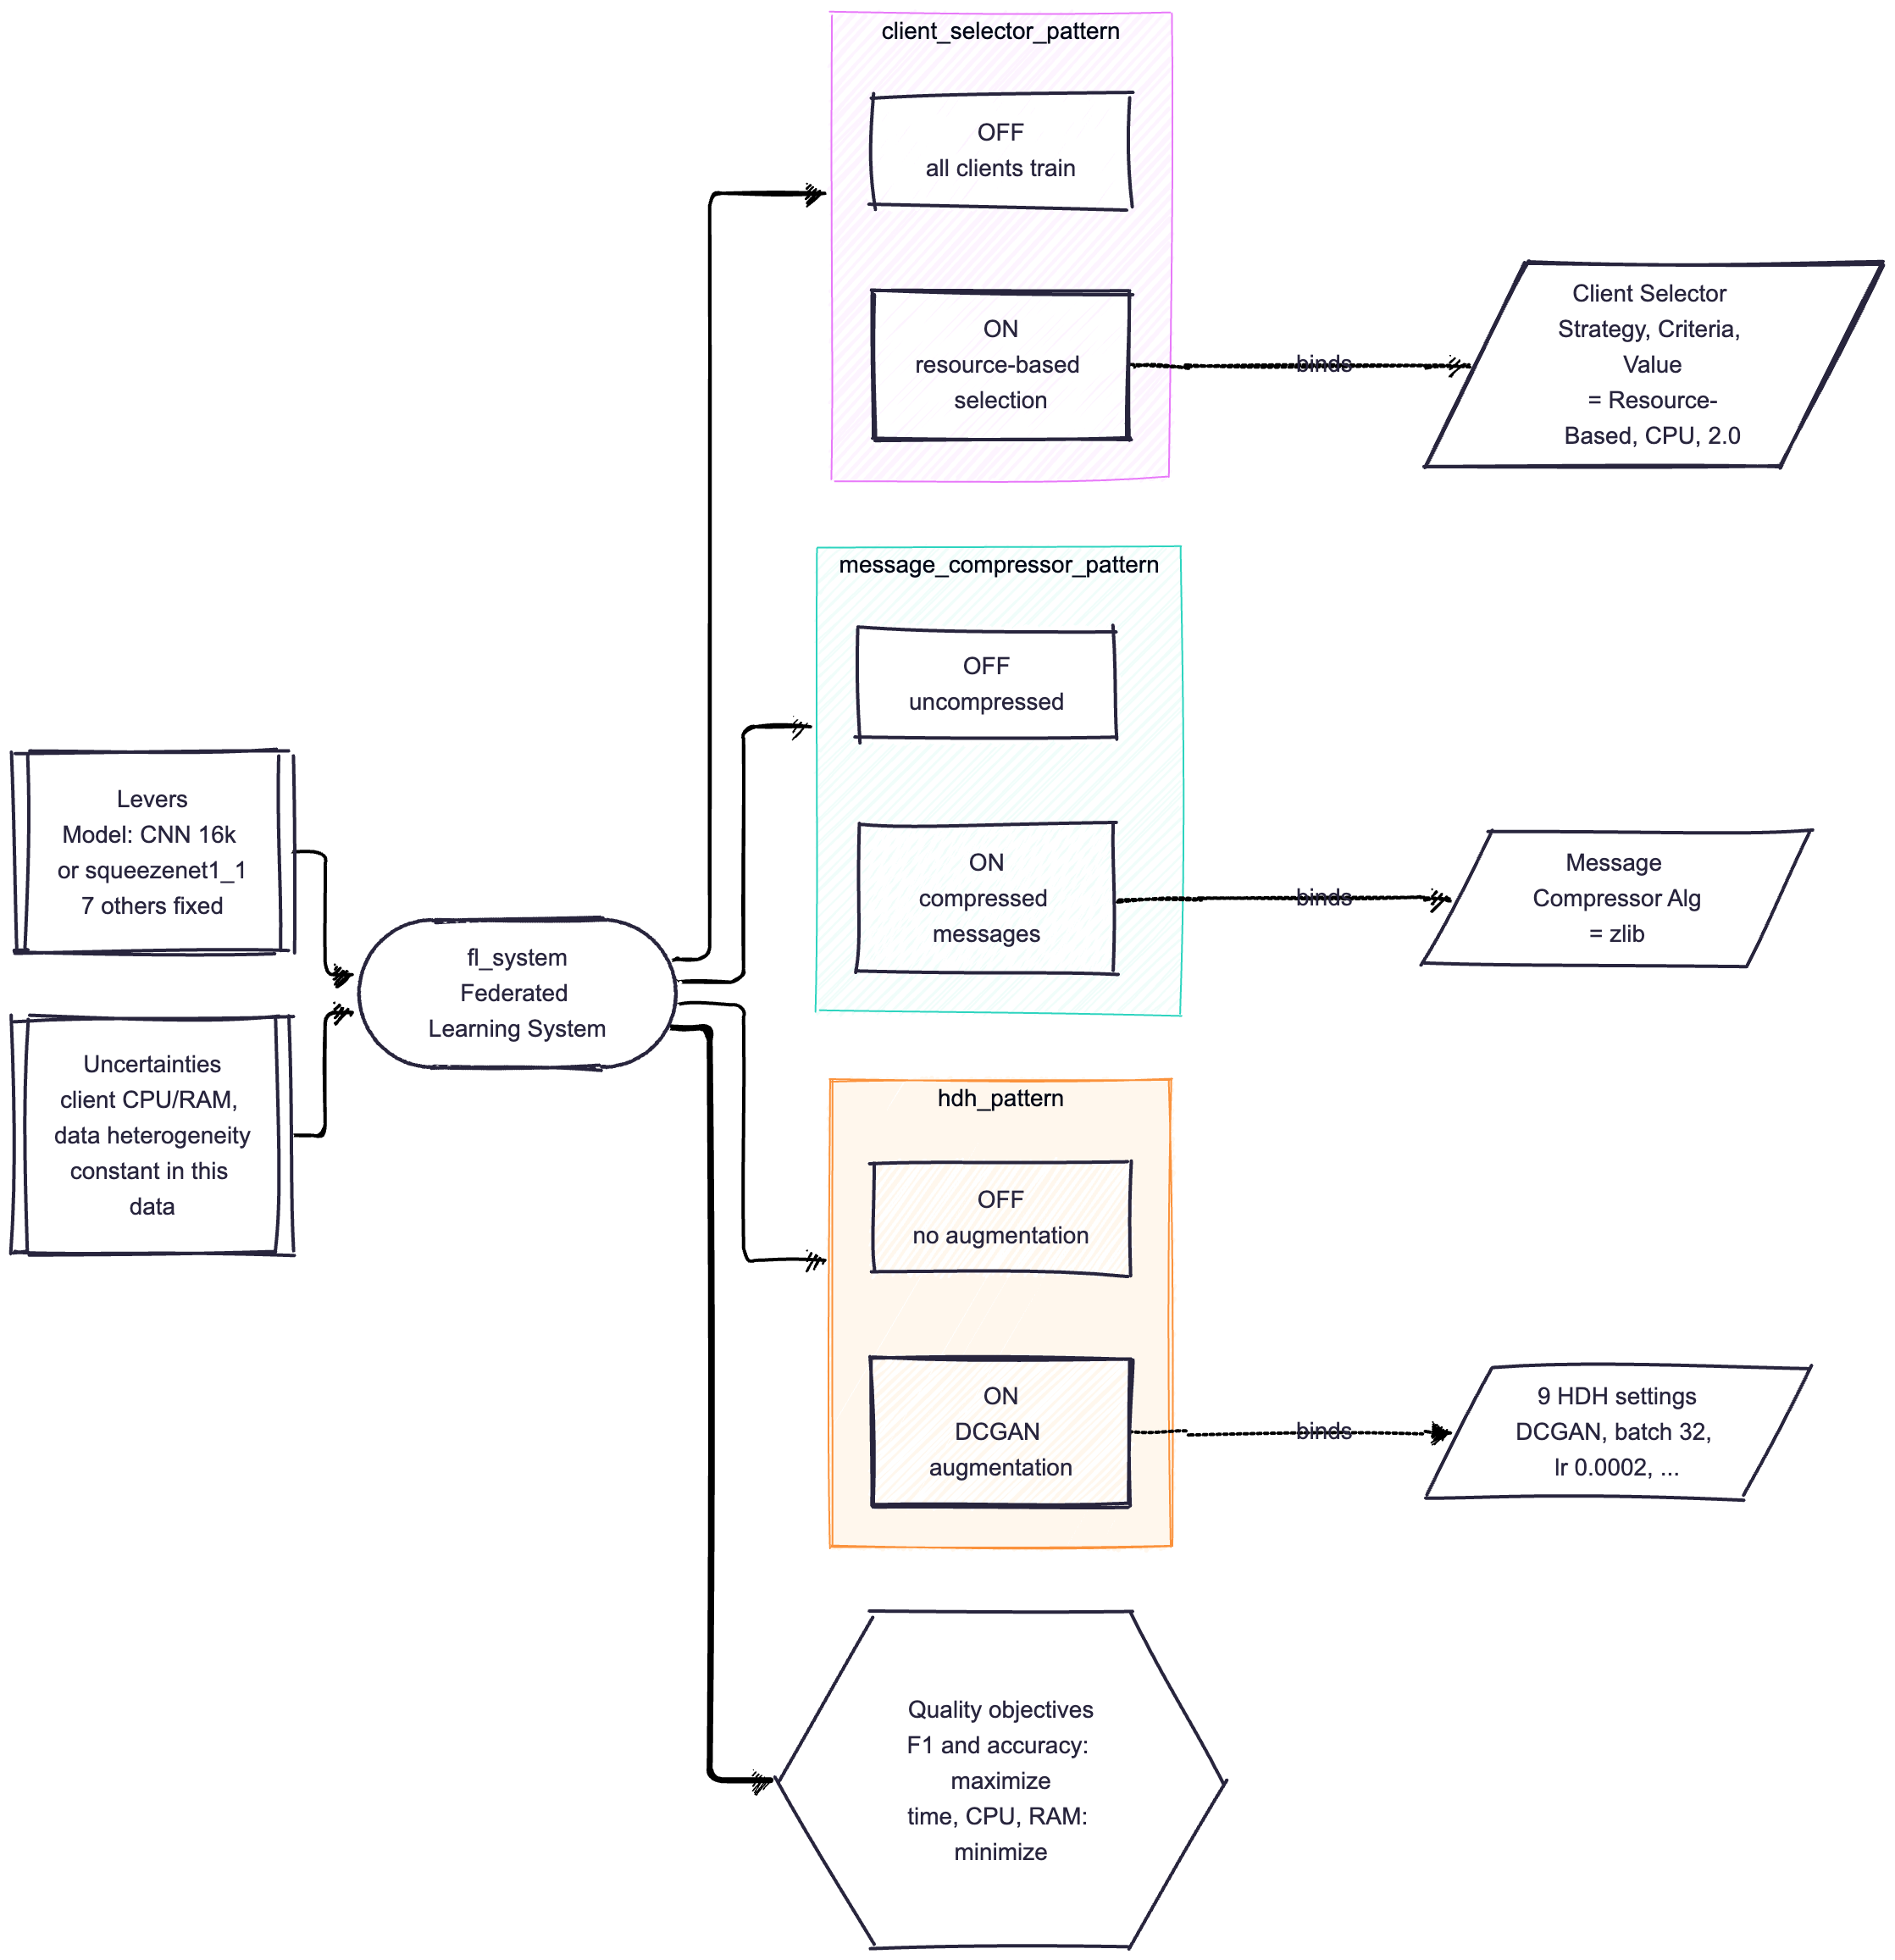

### The design space at a glance

`fl_system` is a single component that composes **three independent ON/OFF pattern decisions**. Each `ON` policy binds a fixed set of constraint parameters; each `OFF` policy binds nothing.

#### Configurations

A configuration fixes one policy per decision, written `client_selector,message_compressor,hdh`. Only **4 of the 8** combinations were run: the baseline and each pattern on its own.

| Configuration | Name | Runs |
|:---|:---|---:|
| `OFF,OFF,OFF` | All Patterns Off (baseline) | 10 |
| `ON,OFF,OFF` | Client Selector Only | 10 |
| `OFF,ON,OFF` | Message Compressor Only | 5 |
| `OFF,OFF,ON` | HDH Only | 7 |

#### Parameters

27 parameters are declared, but few of them vary across the 32 runs:

| Kind | Count | What varies in the data |
|:---|---:|:---|
| **Levers** (system settings) | 8 | only `Model` (`CNN 16k` vs. `squeezenet1_1`); rounds, clients, dataset, optimizer, learning rate, batch size and epochs are fixed |
| **Constraints** (pattern settings) | 13 | one fixed value when their pattern is ON, empty (NaN) when OFF, so each only records *whether* its pattern is on |
| **Uncertainties** (client environment) | 6 | nothing: CPU/RAM allocation and data-heterogeneity measures are constant (`JSD Mean` is only recorded with HDH ON) |

#### Quality objectives

| Group | Objectives | Direction |
|:---|:---|:---|
| Model quality | `best_val_f1`, `final_val_f1`, `final_val_accuracy` | maximize |
| Cost | `avg_total_time`, `avg_training_time`, `avg_communication_time`, `CPU Usage Avg Mean`, `RAM Usage Avg Mean` | minimize |

The analysis targets **model accuracy × total round time** (`final_val_accuracy` × `avg_total_time`), the classic FL tradeoff (Section 3).

> **Takeaway.** In practice the design space is **configuration × model**, with 7 populated combinations (Message Compressor Only was run with `CNN 16k` only). The data compares each pattern against the baseline, but never two patterns together, so pattern interactions are outside its reach.

## 2. Linter Sanity Check (R1-R3, U1)

Before building any analysis on top of the spec, we explicitly re-run
`SystemLinter` and inspect its findings. We lint against `session.raw_df`
(parameters + quality objectives combined) rather than `session.experiments_df`
(parameters only): `experiments_df` alone lacks the quality-objective columns
the linter checks for, which would otherwise misfire as 8 false "objective not
found" `ERROR`s. This matches how `GenericDataLoader.validate_data_integrity`
invokes the linter internally during `session.load()` (it lints the combined
raw dataframe, not the post-split experiments-only frame).

We expect zero `ERROR`s, one policy-combination coverage `WARNING` (4 of 8
combinations declared), and low-variance `WARNING`s on the fixed levers, on all 6
of FL's aggregated client-heterogeneity parameters (R7), on the HDH and
message-compressor parameters, and on `RAM Usage Avg Mean`. We expect no NaN-semantics warnings: every parameter
with NaNs is declared `optional`, and no objective has NaNs. The notebook should
not proceed past a spec the linter reports errors for.

In [3]:
issues = SystemLinter().lint(session.sys_def, session.raw_df)
errors = [i for i in issues if i.level == "ERROR"]
warnings_ = [i for i in issues if i.level == "WARNING"]

print(f"Linter findings: {len(errors)} ERROR(s), {len(warnings_)} WARNING(s)")
for issue in issues:
    print(" ", issue)

assert not errors, f"Linter reported ERROR-level issues; fix the spec before proceeding: {errors}"

Linter findings: 0 ERROR(s), 25 WARNING(s)
  [WARNING] Dataspace.Configurations: Component 'fl_system' has incomplete policy-combination coverage: 4 of 8 combinations declared (decisions: client_selector_pattern, message_compressor_pattern, hdh_pattern). Missing combinations: OFF,ON,ON, ON,OFF,ON, ON,ON,OFF, ON,ON,ON.
  [WARNING] Dataspace.QualityObjectives: Quality Objective 'RAM Usage Avg Mean' is low-variance: 78.1% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'N Rounds' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'Total Clients' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Components: Parameter 'Dataset' (Component: fl_system) is low-variance: 100.0% of values are concentrated on a single value (threshold 70%).
  [WARNING] System.Component

### What the linter tells us about the design space

| Warning | Meaning for the analysis |
|:---|:---|
| **Coverage: 4 of 8 combinations** | Expected: this is a one-pattern-at-a-time design. Every pattern conclusion is relative to the all-OFF baseline. |
| **Low variance at 100%** (fixed levers, all uncertainties) | These parameters have a single value, so they cannot explain any difference between runs. Feature scoring (Section 7) will give them zero importance. |
| **Low variance at 78-84%** (HDH and compressor parameters, `JSD Mean`) | Only low-variance because they are empty whenever their pattern is OFF. They carry "pattern on or off", not a tunable value. |
| **`RAM Usage Avg Mean`** | 78% of runs share one value, so it would be a weak objective for defining tradeoffs. |

> **Takeaway.** No errors, and every warning is explained by how the experiment was designed. The only factors that can explain differences between runs are the **configuration** and the **model**.

In [4]:
print(f"Loaded {len(session.raw_df)} experiments.")
session.raw_df.head()

Loaded 32 experiments.


,N Rounds,Total Clients,Model,Dataset,Optimizer,Learning Rate,Batch Size,Epochs,Client 1 ID,Client 1 CPU,...,hdh_pattern,config_id,CPU Mean,RAM Mean,Data Distribution Diversity,Data Persistence Diversity,Alpha Dirichlet Mean,JSD Mean,CPU Usage Avg Mean,RAM Usage Avg Mean
0,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"OFF,OFF,OFF",2.6,2.0,2,1,0.8,NaN,116.78,2.0
1,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"OFF,OFF,OFF",2.6,2.0,2,1,0.8,NaN,109.46,2.0
2,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"OFF,OFF,OFF",2.6,2.0,2,1,0.8,NaN,109.46,2.0
3,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"OFF,OFF,OFF",2.6,2.0,2,1,0.8,NaN,111.38,2.0
4,10,5,CNN 16k,CIFAR-10,Adam,0.001,64,1,Client 1,3,...,OFF,"OFF,OFF,OFF",2.6,2.0,2,1,0.8,NaN,112.44,2.0


## 3. Define Tradeoffs (R9)

FL declares 8 quality objectives (6 original + 2 new telemetry objectives from
R8), but only 32 experiment rows. Discretizing all 8 objectives combinatorially
(3 bins each = 3^8 = 6,561 possible tradeoffs) would be intractable and
meaningless at this sample size -- almost every combination would be empty.
We instead discretize the **classic FL tradeoff** into 3 bins per objective:

- **model accuracy**: `final_val_accuracy`, the accuracy of the global model after the last round (maximize);
- **total round time**: `avg_total_time`, the average wall-clock time of a round, training plus communication (minimize). With 10 rounds in every run, total training time is 10x this value.

This mirrors the Gateway Offloading notebook's use of a small, meaningful objective
pair. F1 ranks the runs almost exactly like accuracy (Spearman 0.985 between
`final_val_accuracy` and `best_val_f1`), so it is kept as a robustness check, not a
second target.

In [5]:
# ---- Discretization objectives into 3 bins
target_labels = {
    'final_val_accuracy': ['S', 'M', 'L'],
    'avg_total_time': ['S', 'M', 'L']    
}
tradeoffs, schemes = session.create_tradeoffs(method='discretization', labels=target_labels)

print(len(tradeoffs), "possible tradeoffs (regions)")
for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")

Creating discretization tradeoffs with 3 bins.
9 possible tradeoffs (regions)
Objective: final_val_accuracy
  S: [0.21, 0.34]
  M: [0.34, 0.46]
  L: [0.46, 0.58]
Objective: avg_total_time
  S: [17.26, 195.68]
  M: [195.68, 374.10]
  L: [374.10, 552.52]


### The target tradeoffs

We keep one quality objective and one cost objective, each split into three bins:

| Objective | Direction | `S` | `M` | `L` | Best bin |
|:---|:---|:---|:---|:---|:---|
| `final_val_accuracy` | maximize | 0.212-0.336 | 0.336-0.460 | 0.460-0.584 | `L` |
| `avg_total_time` | minimize | 17-196 | 196-374 | 374-553 | `S` |

A tradeoff is named `<accuracy bin>-<time bin>`: `L-S` (high accuracy, fast) is the ideal region and `S-L` (low accuracy, slow) the worst. The 32 runs fall into **7 of the 9 regions**; `S-M` and `S-L` are empty.

| Region | Meaning | Runs | Which runs |
|:---|:---|---:|:---|
| `S-S` | low accuracy, fast | 17 | `CNN 16k`: All Patterns Off (5), HDH Only (5), Message Compressor Only (5), Client Selector Only (2) |
| `M-S` | medium accuracy, fast | 3 | `CNN 16k`: Client Selector Only (3) |
| `M-M` | medium accuracy, medium time | 2 | `squeezenet1_1`: All Patterns Off |
| `M-L` | medium accuracy, slow | 2 | `squeezenet1_1`: HDH Only |
| `L-S` | **high accuracy, fast (ideal)** | 1 | `squeezenet1_1`: Client Selector Only |
| `L-M` | high accuracy, medium time | 6 | `squeezenet1_1`: Client Selector Only (4), All Patterns Off (2) |
| `L-L` | high accuracy, slow | 1 | `squeezenet1_1`: All Patterns Off |

#### How each factor moves the objectives

Mean values compared against the all-OFF baseline **for the same model**. Groups have only 2-10 runs, so treat these as tendencies to verify, not effect sizes.

| Factor | `final_val_accuracy` (maximize) | `avg_total_time` (minimize) |
|:---|:---|:---|
| `squeezenet1_1` instead of `CNN 16k` | +0.135 (about +42%) | about 9x slower |
| client selector ON | +0.013 on `CNN 16k`, +0.020 on `squeezenet1_1` | +6% on `CNN 16k` (same bin), 18% faster on `squeezenet1_1` |
| HDH ON | +0.006 on `CNN 16k`, **-0.016** on `squeezenet1_1` | 32% slower on `CNN 16k`, 58% slower on `squeezenet1_1` |
| message compressor ON (`CNN 16k` runs only) | +0.005 | 16% slower |

> **Takeaway.**
> - **The model dominates:** `squeezenet1_1` buys about 42% more accuracy at about 9x the time. Pattern effects are best read within one model.
> - **The client selector is the only pattern that helps:** it raises accuracy on both models without adding a time tier. Every `squeezenet1_1` selector run reaches the high-accuracy bin, and 3 of 5 `CNN 16k` selector runs cross into the medium one. On `squeezenet1_1` it is even faster.
> - **HDH is a cost, and on the large model a loss:** it slows rounds on both models and lowers `squeezenet1_1` accuracy, so its runs alone form the `M-L` region.
> - **The message compressor** was only run with `CNN 16k`, where it is 16% slower than the baseline with no clear accuracy change: its intended communication saving does not show in this data.

## 4. Data Splitting

We split into train/test sets, stratified by tradeoff membership, to support
both feature scoring (train, Section 7) and box evaluation (test, Sections
8-10).

In [6]:
session.split_data(test_size=0.3, remove_outliers=False, verbose=True)

Data split: 22 train, 10 test.

--- Train Set Tradeoff Counts ---
  S,S: 12 (54.55%)
  M,S: 2 (9.09%)
  M,M: 2 (9.09%)
  M,L: 1 (4.55%)
  L,S: 1 (4.55%)
  L,M: 3 (13.64%)
  L,L: 1 (4.55%)

--- Test Set Tradeoff Counts ---
  S,S: 5 (50.00%)
  M,S: 1 (10.00%)
  M,M: 0 (0.00%)
  M,L: 1 (10.00%)
  L,S: 0 (0.00%)
  L,M: 3 (30.00%)
  L,L: 0 (0.00%)


### Reading the split

The split tries to keep each tradeoff region's share equal in train and test. `L-S` and `L-L` have a single run each, so it falls back to a random (seeded, reproducible) split.

| | Train | Test |
|:---|---:|---:|
| Runs | 22 | 10 |
| Regions present | all 7 populated regions | 4 (`S-S`, `M-S`, `M-L`, `L-M`) |

The test set holds only 1-2 runs per model and configuration:

| Model | All Patterns Off | Client Selector Only | Message Compressor Only | HDH Only |
|:---|---:|---:|---:|---:|
| `CNN 16k` | 1 | 2 | 2 | 1 |
| `squeezenet1_1` | 1 | 2 | - | 1 |

> **What this means later.** Scenario discovery (Sections 8-9) learns on the 22 training runs and is scored on the 10 test runs. The regions `M-M`, `L-S` (ideal) and `L-L` have no test run, so boxes found for them cannot be validated. Test-set robustness values move in large steps: with 2 runs in a group, the only possible success rates are 0, 0.5 and 1.

We visually confirm the spread of our metrics. 

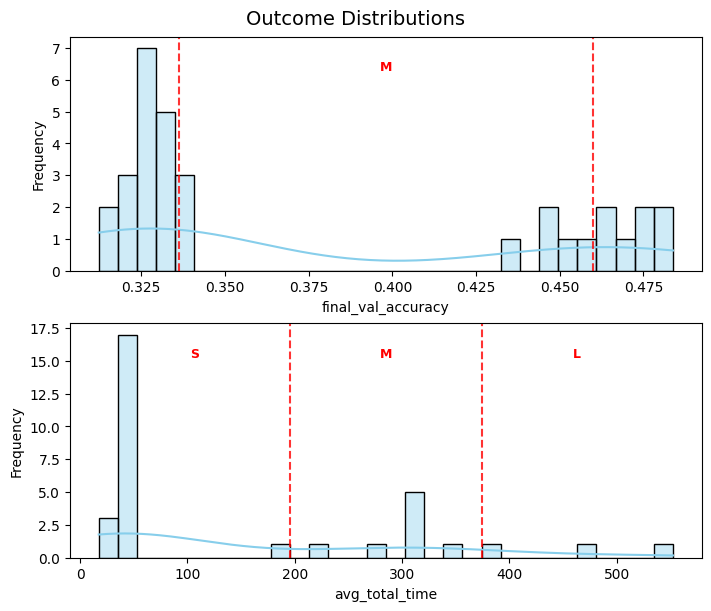

In [7]:
session.show_distributions(figsize=(7,3))
plt.show()

### How to read `S`, `M` and `L`

Each objective's range is cut into **three equal-width bins**. The labels describe the *value*, not its quality:

- **`S`, `M`, `L` = small, medium, large value.** Whether that is good depends on the objective's direction: for `final_val_accuracy` (maximize) `L` is best; for `avg_total_time` (minimize) `S` is best.
- **Labels are relative to this dataset.** An `L` accuracy means "among the highest accuracies in these 32 runs" (the best run reaches 0.48 on CIFAR-10), not a good accuracy in absolute terms.
- **The bins are narrower than they look.** They span the observed range padded by 0.1 (in objective units) on each side. That padding is negligible for time, but large for accuracy, whose runs only span 0.312-0.484:

| Objective | Bin | Nominal range | Where the runs actually are |
|:---|:---:|:---|:---|
| `final_val_accuracy` | `S` | 0.212-0.336 | 0.312-0.336, `CNN 16k` runs only |
| | `M` | 0.336-0.460 | 3 `CNN 16k` Client Selector Only runs (0.336-0.339) and the lower `squeezenet1_1` runs (HDH Only, 2 of All Patterns Off) |
| | `L` | 0.460-0.584 | 0.460-0.484: every `squeezenet1_1` Client Selector Only run and 3 of All Patterns Off |
| `avg_total_time` | `S` | 17-196 | every `CNN 16k` run (all under 51) and one `squeezenet1_1` run |
| | `M` | 196-374 | most `squeezenet1_1` runs |
| | `L` | 374-553 | 3 `squeezenet1_1` runs: All Patterns Off (1), HDH Only (2) |

The accuracy histogram is **bimodal**, one cluster per model (`CNN 16k` 0.312-0.339, `squeezenet1_1` 0.437-0.484). **Both inner edges cut through a cluster:** 0.336 through the `CNN 16k` one, and 0.460 through the `squeezenet1_1` baseline runs (0.447-0.465). A difference of about 0.01 accuracy can therefore change a run's bin. Keep that in mind whenever a pattern "moves a run up a bin", or when runs of the same configuration land in different regions.

> **Tip.** To cut an objective at meaningful limits instead of equal widths, use `create_tradeoffs(method='threshold', thresholds={...})`, for example `thresholds={'final_val_accuracy': 0.40, 'avg_total_time': 200}`.

We map the tradeoffs onto a 2D space to see their shape and density. Readability enhancements include bottom-aligned legends and bottom-to-top orientation for Y-axis bin labels.

In [8]:
tradeoff_labels = [t.name for t in tradeoffs]
tradeoff_labels

['S-S', 'S-M', 'S-L', 'M-S', 'M-M', 'M-L', 'L-S', 'L-M', 'L-L']

In [9]:
session.get_decisions()

{'client_selector_pattern': Decision(description='Pattern for selecting which clients participate in training', policies={'OFF': PatternPolicy(description='Client selector pattern disabled - all clients participate', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Client selector pattern enabled - Resource-Based selection', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={'Client Selector Strategy': 'Resource-Based', 'Client Selector Criteria': 'CPU', 'Client Selector Value': 2.0}))}),
 'message_compressor_pattern': Decision(description='Pattern for compressing messages exchanged between clients and server', policies={'OFF': PatternPolicy(description='Message compressor disabled', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Message compressor enabled - zlib compression', parameter_bindings=ParameterBindings(levers={}

In [10]:
session.get_policies()

{'OFF,OFF,OFF': SystemConfiguration(name='All Patterns Off', description='No adaptive patterns enabled', pattern_policy_references=[PatternPolicyReference(component='fl_system', decision='client_selector_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='message_compressor_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='hdh_pattern', policy='OFF')], source_file=None, component_policies={}),
 'ON,OFF,OFF': SystemConfiguration(name='Client Selector Only', description='Only client selector pattern enabled', pattern_policy_references=[PatternPolicyReference(component='fl_system', decision='client_selector_pattern', policy='ON'), PatternPolicyReference(component='fl_system', decision='message_compressor_pattern', policy='OFF'), PatternPolicyReference(component='fl_system', decision='hdh_pattern', policy='OFF')], source_file=None, component_policies={}),
 'OFF,ON,OFF': SystemConfiguration(name='Message Compressor Only', descripti

### Decisions, policies and configurations

The two cells above list the same design space at two levels:

| Term | What it is | In this system | Where to see it |
|:---|:---|:---|:---|
| **Decision** | a design choice point for one pattern | `client_selector_pattern`, `message_compressor_pattern`, `hdh_pattern` | `get_decisions()` |
| **Policy** | one option of a decision; it binds values to constraint parameters | `ON` or `OFF` for each decision | `get_decisions()[d].policies` |
| **Configuration** | one policy per decision, i.e. a full system variant | `OFF,OFF,OFF`, `ON,OFF,OFF`, `OFF,ON,OFF`, `OFF,OFF,ON` | `get_policies()`, column `config_id` |

Note that `get_policies()` returns **configurations** (ADEPT calls them system-level policies). Robustness results (Sections 6 and 10) are reported per configuration by default; pass `by='decision'` to report per decision policy instead (e.g. `hdh_pattern:ON`).

#### What else the model contains

| Element | Role | Examples |
|:---|:---|:---|
| **Levers** | design settings not tied to a pattern, controlled by the architect | `Model`, rounds, learning rate |
| **Constraints** | the settings a pattern's `ON` policy fixes; empty when the pattern is OFF, which ADEPT encodes as a separate "not selected" value | `Client Selector Value` = 2.0, `HDH Latent Dim` = 100 |
| **Uncertainties** | environment conditions the architect does not control | client CPU/RAM, data heterogeneity |
| **Quality objectives** | measured outcomes of each run | `final_val_accuracy`, `avg_total_time` (analyzed); 6 others stay in the spec but are excluded from `outcomes_df` (see the warning in Section 3) |

All three parameter kinds are candidate *explanations* of the objectives: Section 7 scores how much each one matters, and Sections 8-9 describe tradeoff regions as ranges over the top-ranked ones.

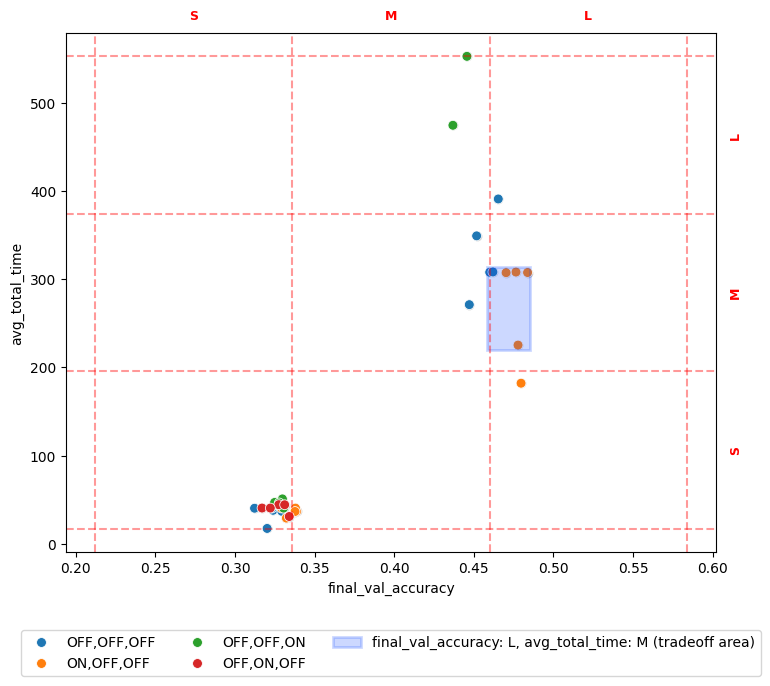

In [11]:
outcome_cols = list(session.outcomes_df.columns)
# Plot the policies for all combinations (pairs) of quality objectives
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    fig = session.show_quality_objective_space(
        x_col, y_col,
        highlight_policies=session.get_policies(), 
        highlight_tradeoffs=[session.get_tradeoff(tradeoffs[7].name)],
        # show_overall=True,
        subset='all',
        cmap='tab10', 
        alpha=1.0,
        figsize=(8, 7),
        s=50,
        title=""
    )
    # fig.savefig(f'fl-quality_objective_space_{x_col}_{y_col}.png', dpi=500)
    plt.show()

### Reading the objective space

- **Points and colors.** Each point is one run, colored by its configuration.
- **Grid.** The dashed lines are the bin edges, so each grid cell is one tradeoff region: columns are the accuracy bin (`S`, `M`, `L` from left to right), rows the time bin (`S`, `M`, `L` from bottom to top). The ideal region `L-S` is the bottom-right cell.
- **Bottom left: the `CNN 16k` runs.** All fast (under 51) with accuracy 0.31-0.34. Client Selector Only (orange) sits at the right edge of this cluster, 3 of its 5 runs just past the `S`/`M` line.
- **Outlined region.** The plot outlines `tradeoffs[7]`, i.e. `L-M` (high accuracy, medium time), where 4 `squeezenet1_1` Client Selector Only runs and 2 baseline runs sit.
- **Upper right: the `squeezenet1_1` runs.** About 1.4x the accuracy at about 9x the time on average. Client Selector Only (orange) reaches the highest accuracy, including the single `L-S` run (accuracy about 0.48, time about 182). HDH Only (green) gives the slowest runs and the lowest accuracy of this model (region `M-L`). The baseline runs straddle the `M`/`L` accuracy edge.

## 5. Per-Decision Contingency Analysis (R9)

For each of FL's 3 composed pattern decisions (`client_selector_pattern`,
`message_compressor_pattern`, `hdh_pattern`), we compute the contingency
between policy choice and tradeoff outcome, and identify deterministic
policies and tradeoffs each decision exclusively unlocks.

In [12]:
session.get_decisions()

{'client_selector_pattern': Decision(description='Pattern for selecting which clients participate in training', policies={'OFF': PatternPolicy(description='Client selector pattern disabled - all clients participate', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Client selector pattern enabled - Resource-Based selection', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={'Client Selector Strategy': 'Resource-Based', 'Client Selector Criteria': 'CPU', 'Client Selector Value': 2.0}))}),
 'message_compressor_pattern': Decision(description='Pattern for compressing messages exchanged between clients and server', policies={'OFF': PatternPolicy(description='Message compressor disabled', parameter_bindings=ParameterBindings(levers={}, uncertainties={}, constraints={})), 'ON': PatternPolicy(description='Message compressor enabled - zlib compression', parameter_bindings=ParameterBindings(levers={}

FL decisions: ['client_selector_pattern', 'message_compressor_pattern', 'hdh_pattern']
Analyzing Decision: client_selector_pattern


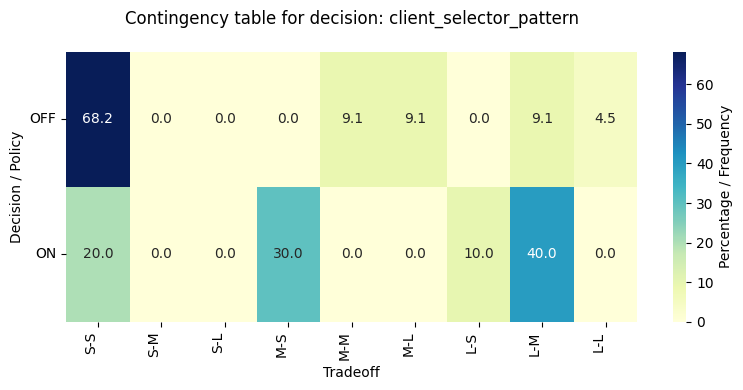

Analyzing Decision: message_compressor_pattern


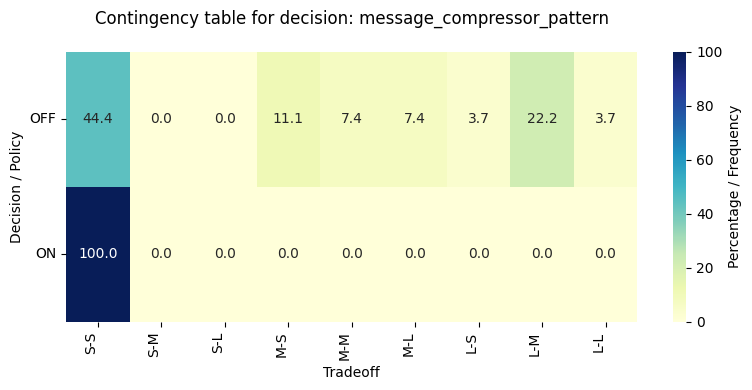

Analyzing Decision: hdh_pattern


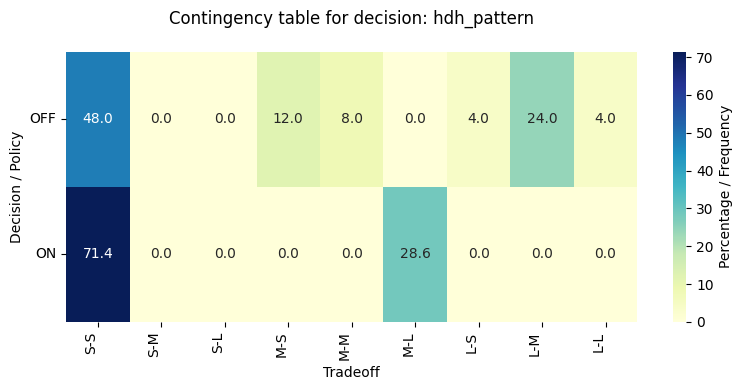

In [13]:
decisions = list(session.get_decisions().keys())
print("FL decisions:", decisions)

for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(
        decision_key,
        type='heatmap',
        subset='all',
        title=f"Contingency table for decision: {decision_key}",
        figsize=(8, 4)
    )
    plt.show()

In [14]:
print("Deterministic policies (policies that consistently result in a single specific tradeoff)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_deterministic_policies(decision_key):
        print("* Policy:", policy, "--> Tradeoff:", tradeoff)

Deterministic policies (policies that consistently result in a single specific tradeoff)
------------------------------
Decision: client_selector_pattern
------------------------------
Decision: message_compressor_pattern
* Policy: ON --> Tradeoff: S-S
------------------------------
Decision: hdh_pattern


In [15]:
print("Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)")
for decision_key in decisions:
    print("---" * 10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_exclusive_tradeoffs(decision_key):
        print("* Tradeoff:", tradeoff, "--> Decision:", decision_key, "[Policy:", policy, "]")

Exclusive tradeoffs (tradeoffs reachable through only one decision's policy)
------------------------------
Decision: client_selector_pattern
* Tradeoff: M-S --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: M-M --> Decision: client_selector_pattern [Policy: OFF ]
* Tradeoff: M-L --> Decision: client_selector_pattern [Policy: OFF ]
* Tradeoff: L-S --> Decision: client_selector_pattern [Policy: ON ]
* Tradeoff: L-L --> Decision: client_selector_pattern [Policy: OFF ]
------------------------------
Decision: message_compressor_pattern
* Tradeoff: M-S --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: M-M --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: M-L --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: L-S --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: L-M --> Decision: message_compressor_pattern [Policy: OFF ]
* Tradeoff: L-L --> Decision: message_compressor_pattern [Policy: OFF ]
---------------

## 6. Robustness Analysis (Quantifying Stability)
While contingency tells us *how often* we succeed, robustness tells us *how stable* that success is when parameters vary. We use two complementary metrics:
- **STARR (Success Rate)**: The percentage of points within a policy that meet the target requirements. Higher is better.
- **REGRET (Risk)**: The standardized distance from the closest successful point. It measures 'how bad' a failure is. Lower is better.

In [16]:
metric = 'starr' #'starr' 'regret'

In [17]:
base_robustness_matrix = session.get_robustness_report(metric=metric, subset='test') 
base_robustness_matrix # Test

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
policy,,,,,,,,,
"OFF,OFF,OFF",0.50,0.0,0.0,0.00,0.0,0.0,0.0,0.5,0.0
"OFF,OFF,ON",0.50,0.0,0.0,0.00,0.0,0.5,0.0,0.0,0.0
"OFF,ON,OFF",1.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
"ON,OFF,OFF",0.25,0.0,0.0,0.25,0.0,0.0,0.0,0.5,0.0


Robustness Ranking for Tradeoff: S-S
  1. OFF,ON,OFF: 100% success
  2. OFF,OFF,ON: 71% success
  3. OFF,OFF,OFF: 50% success
  Top Policy -> OFF,ON,OFF - Starr: 1.0000 - Regret: 0.0000
Robustness Ranking for Tradeoff: S-M
  1. OFF,OFF,OFF: 0% success
  2. OFF,OFF,ON: 0% success
  3. OFF,ON,OFF: 0% success
  Top Policy -> OFF,OFF,OFF - Starr: 0.0000 - Regret: 1.4426
Robustness Ranking for Tradeoff: S-L
  1. OFF,OFF,OFF: 0% success
  2. OFF,OFF,ON: 0% success
  3. OFF,ON,OFF: 0% success
  Top Policy -> OFF,OFF,OFF - Starr: 0.0000 - Regret: 2.0476
Robustness Ranking for Tradeoff: M-S
  1. ON,OFF,OFF: 30% success
  2. OFF,OFF,OFF: 0% success
  3. OFF,OFF,ON: 0% success
  Top Policy -> ON,OFF,OFF - Starr: 0.3000 - Regret: 0.3124
Robustness Ranking for Tradeoff: M-M
  1. OFF,OFF,OFF: 20% success
  2. OFF,OFF,ON: 0% success
  3. OFF,ON,OFF: 0% success
  Top Policy -> OFF,OFF,OFF - Starr: 0.2000 - Regret: 0.5549
Robustness Ranking for Tradeoff: M-L
  1. OFF,OFF,ON: 29% success
  2. OFF,OFF,OF

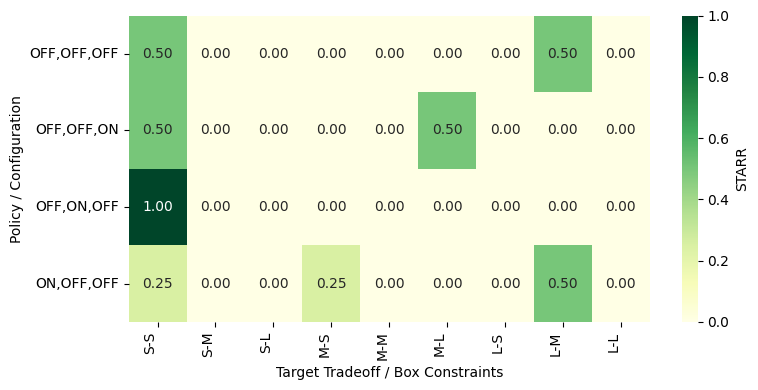

In [18]:
for tradeoff in session.get_tradeoffs():
    print(f"Robustness Ranking for Tradeoff: {tradeoff.name}")
    ranking = session.get_policy_robustness_ranking(tradeoff.name, metric='starr')
    for i, (pol, val) in enumerate(ranking[:3]):
        print(f"  {i+1}. {pol}: {val:.0%} success")
    
    if ranking:
        top_pol = ranking[0][0]
        starr = session.compute_robustness(top_pol, tradeoff.name, metric='starr')
        regret = session.compute_robustness(top_pol, tradeoff.name, metric='regret')
        print(f"  Top Policy -> {top_pol} - Starr: {starr.get('value', 0.0):.4f} - Regret: {regret.get('value', 0.0):.4f}")

if metric == 'starr':
    print("Overall Robustness Heatmap (STARR):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='starr', figsize=(8,4))
    plt.show()

if metric == 'regret':
    print("Overall Robustness Heatmap (REGRET):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='regret', figsize=(8,4), title=metric)
    plt.show()

## 7. Feature Importance & Key-Parameter Selection (R6)

`compute_feature_scores` is called with `include_constraints=True` -- the R6
fix's call site (KTD3: no production code change was needed, only correct
notebook usage). This makes FL's 13 existing policy-bound pattern parameters
(Client Selector Strategy/Criteria/Value, Message Compressor Alg, and the 9
HDH parameters) participate in feature-importance scoring instead of being
silently dropped by the framework's `include_constraints=False` default.

Categorical parameters (such as `Model`) and optional ones (empty when their pattern
is OFF) are encoded numerically before scoring (see `docs/nan_strategy.md`), so
every declared parameter is scored. How to read the scores:

- **`Model` dominates** both objectives (importance about 0.98 for accuracy and 0.89
  for time); every other parameter scores below 0.1.
- **One parameter per pattern.** Smart correlation keeps a single parameter from each
  group of perfectly correlated ones, so `Client Selector Criteria` stands for "client
  selector ON" and `HDH Batch Size` for "HDH ON". The other parameters of the same
  pattern score 0 because they are redundant, not because the pattern is irrelevant.
  Ties are broken alphabetically, so the representative is the same in every run.
- **Constant parameters** (fixed levers, client-environment uncertainties) score 0.

In [19]:
scores_df = session.compute_feature_scores(
    use_smart_correlation=True,
    include_constraints=True,
    subset='train'
)
scores_df

Scoring features for outcome: final_val_accuracy (on subset: train)
Original features (numerically encoded): ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Strategy', 'Client Selector Criteria', 'Client Selector Value', 'Message Compressor Alg', 'HDH Batch Size', 'HDH Beta 1', 'HDH Beta 2', 'HDH Discriminator', 'HDH Epochs', 'HDH Generator', 'HDH Learning Rate', 'HDH Latent Dim', 'HDH Optimizer', 'CPU Mean', 'RAM Mean', 'Alpha Dirichlet Mean', 'JSD Mean', 'Data Distribution Diversity', 'Data Persistence Diversity']


Features selected: ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Criteria', 'Message Compressor Alg', 'HDH Batch Size', 'CPU Mean', 'RAM Mean', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Data Persistence Diversity']
Scoring features for outcome: avg_total_time (on subset: train)
Original features (numerically encoded): ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Strategy', 'Client Selector Criteria', 'Client Selector Value', 'Message Compressor Alg', 'HDH Batch Size', 'HDH Beta 1', 'HDH Beta 2', 'HDH Discriminator', 'HDH Epochs', 'HDH Generator', 'HDH Learning Rate', 'HDH Latent Dim', 'HDH Optimizer', 'CPU Mean', 'RAM Mean', 'Alpha Dirichlet Mean', 'JSD Mean', 'Data Distribution Diversity', 'Data Persistence Diversity']


Features selected: ['N Rounds', 'Total Clients', 'Model', 'Dataset', 'Optimizer', 'Learning Rate', 'Batch Size', 'Epochs', 'Client Selector Criteria', 'Message Compressor Alg', 'HDH Batch Size', 'CPU Mean', 'RAM Mean', 'Alpha Dirichlet Mean', 'Data Distribution Diversity', 'Data Persistence Diversity']


,final_val_accuracy,avg_total_time
Alpha Dirichlet Mean,0.000000,0.000000
Batch Size,0.000000,0.000000
CPU Mean,0.000000,0.000000
Client Selector Criteria,0.013278,0.030894
Client Selector Strategy,0.000000,0.000000
Client Selector Value,0.000000,0.000000
Data Distribution Diversity,0.000000,0.000000
Data Persistence Diversity,0.000000,0.000000
Dataset,0.000000,0.000000
Epochs,0.000000,0.000000


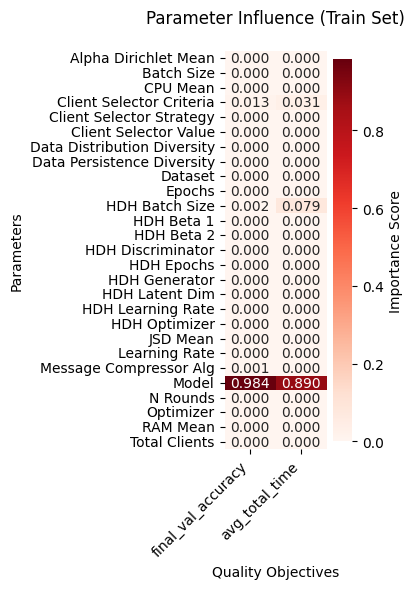

In [20]:
session.show_feature_heatmap(scores_df, title="Parameter Influence (Train Set)", figsize=(4,6))
plt.show()

### R6 regression guard

All 13 of FL's existing pattern parameters must appear in the
feature-importance ranking output. If a future edit reintroduces the
`include_constraints=False` default at this call site, this assertion -- not
silent output -- is what fails `nbconvert --execute`.

In [21]:
FL_PATTERN_PARAMETERS = [
    "Client Selector Strategy", "Client Selector Criteria", "Client Selector Value",
    "Message Compressor Alg",
    "HDH Batch Size", "HDH Beta 1", "HDH Beta 2", "HDH Discriminator", "HDH Epochs",
    "HDH Generator", "HDH Learning Rate", "HDH Latent Dim", "HDH Optimizer",
]
assert len(FL_PATTERN_PARAMETERS) == 13

missing = [p for p in FL_PATTERN_PARAMETERS if p not in scores_df.index]
assert not missing, (
    f"compute_feature_scores(include_constraints=True) dropped pattern parameters: {missing}"
)
print(f"All {len(FL_PATTERN_PARAMETERS)} FL pattern parameters are present "
      f"in the feature-importance ranking (R6 verified).")

All 13 FL pattern parameters are present in the feature-importance ranking (R6 verified).


In [22]:
weighted_features = session.get_weighted_feature_ranking(scores_df)
print("Weighted feature ranking:", weighted_features)

# Categorical parameters (e.g. Model) and optional ones (NaN = pattern not selected)
# are encoded numerically by ADEPT, so every ranked parameter can go to discovery.
# Model dominates the scores (~0.9), so a low threshold (0.03) is needed to also keep
# the pattern parameters with a secondary influence: 'HDH Batch Size' (stands for HDH
# ON/OFF) and 'Client Selector Criteria' (client selector ON/OFF).
key_parameters = session.select_top_k_parameters(
    scores_df, index_order=weighted_features, threshold=0.03, k=None
)
print("Key parameters (for scenario discovery):", key_parameters)

Weighted feature ranking: ['Model', 'HDH Batch Size', 'Client Selector Criteria', 'Message Compressor Alg']
Key parameters (for scenario discovery): ['Model', 'HDH Batch Size', 'Client Selector Criteria']


## 8. Scenario Discovery: PRIM (R9)

PRIM searches, for each tradeoff region, a box over the key parameters from Section 7
(`Model` and the representatives of the client selector and HDH patterns). Box limits
are printed with `readable_limits()`: categorical parameters as sets of categories,
and `includes_na` when the box also covers a pattern's "not selected" (OFF) state.

KTD8's `analyzer_fi` -> `analyzer` fix in `_discover_single_prim`
(`adept/core/session.py`) is required for this cell to run at all: with
`standardize=True`, the unfixed method referenced the undefined name
`analyzer_fi` and raised `NameError` before computing any box.

In [23]:
# Scenario discovery uses the key parameters selected in Section 7 (threshold=0.03).
print("Key parameters (for scenario discovery):", key_parameters)

Key parameters (for scenario discovery): ['Model', 'HDH Batch Size', 'Client Selector Criteria']


In [24]:
prim_boxes = []
non_empty_tradeoffs = session.get_tradeoffs(non_empty=True)
for tradeoff in non_empty_tradeoffs:
    print("---" * 10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(
        tradeoff.name, method='prim',
        threshold=0.8,
        standardize=True,
        parameters=key_parameters
    )
    non_empty_boxes = [b for b in boxes if not b.is_empty()]
    if non_empty_boxes:
        best_box = non_empty_boxes[0]
        print(f"* Key Rules: {best_box.readable_limits()}")
        print(f"* Metrics: {best_box.metrics}")
        prim_boxes.append(best_box)
    else:
        print("--> No scenarios discovered.")

print(f"\n{len(prim_boxes)} non-empty PRIM box(es) discovered across "
      f"{len(non_empty_tradeoffs)} non-empty tradeoffs.")

------------------------------
Discovering scenarios for: S-S
Running PRIM discovery for: S-S ...
Instances satisfying property: True     12
False    10
Name: count, dtype: int64
Total instances: (22, 3)
Running PRIM ... rhodium
3 possible boxes
* Key Rules: {'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['(not selected)'], 'includes_na': True}}
* Metrics: {'density': 1.0, 'coverage': 0.8, 'population_prevalence': 0.5454545454545454, 'lift': 0.4545454545454546, 'samples_in_box': 4.0, 'targets_in_box': 4.0}
------------------------------
Discovering scenarios for: M-S
Running PRIM discovery for: M-S ...
Instances satisfying property: False    20
True      2
Name: count, dtype: int64
Total instances: (22, 3)
Running PRIM ... rhodium
2 possible boxes
* Key Rules: {'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['CPU']}}
* Metrics: {'density': 0.5, 'coverage': 1.0, 'population_prevalence': 0.09090909090909091, 'lift': 0.40909090909090906, 'samples_in_bo

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

In [25]:
boxes_to_keep = []
print("Summary of PRIM boxes:")
for idx, box in enumerate(prim_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.readable_limits()}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
prim_boxes = boxes_to_keep

Summary of PRIM boxes:
 1. For tradeoff S-S (S,S): lift=0.45 
	{'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['(not selected)'], 'includes_na': True}}
 2. For tradeoff M-S (M,S): lift=0.41 
	{'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['CPU']}}
 3. For tradeoff M-L (M,L): lift=0.45 
	{'HDH Batch Size': {'min': 30.4, 'max': 32.0}}
 4. For tradeoff L-M (L,M): lift=0.86 
	{'Model': {'in': ['squeezenet1_1']}, 'Client Selector Criteria': {'in': ['CPU']}}


### Interpreting the PRIM boxes

Each box is a rule over the key parameters that describes the runs of one tradeoff region. Metrics are measured on the 10 test runs: **density** is the share of runs in the box that reach the region, **coverage** the share of the region's runs the box captures, and **lift** is density minus the region's share of training runs (0 = no better than picking runs at random).

The architectural readings rely on the client environment, which is the same in every run: 5 clients, four with 3 CPUs and one (Client 5) with 1 CPU; clients 4 and 5 hold non-IID data. The data shows Client 5 is the straggler that client selection removes: it runs at 100% of its single CPU in every other configuration, and records no activity in any client-selector run. Communication takes about 2 s of each round (35 s on `CNN 16k`, 325 s on `squeezenet1_1` for the baseline).

| Region | Box (decisions) | Architectural reading | Density / coverage |
|:---|:---|:---|:---|
| `S-S` (low accuracy, fast) | `CNN 16k`, client selector OFF | A **low-capacity model with open participation**: every round is cheap, so rounds are fast, but the small model caps accuracy and all five clients, including the 1-CPU straggler, contribute updates. Quality is traded for speed. | 1.0 / 0.8 |
| `M-S` (medium accuracy, fast) | `CNN 16k`, client selector ON | **Resource-based selection** (criterion CPU, threshold 2.0) excludes Client 5, the 1-CPU, non-IID straggler, so aggregation only uses updates from capable clients. Accuracy rises by about 0.013 and rounds stay cheap: a **quality gain at no cost**. The gain is small against the `S`/`M` edge, so only 3 of 5 runs cross it (density 0.5 = 1 of 2 test runs). | 0.5 / 1.0 |
| `M-L` (medium accuracy, slow) | HDH ON | **DCGAN augmentation adds generator training** on every client (training time about +57% on `squeezenet1_1`) and, on the large model, even **lowers accuracy** (-0.016): the region holds exactly the `squeezenet1_1` HDH runs. The box only requires HDH ON, so it also contains the `CNN 16k` HDH runs (which stay in `S-S`); hence density 0.5. | 0.5 / 1.0 |
| `L-M` (high accuracy, medium time) | `squeezenet1_1`, client selector ON | **Capacity and participant quality combine**: the large model gives the accuracy headroom, and selecting capable clients lets it reach the top accuracy tier in every run. Rounds no longer wait for the 1-CPU client, so they are about 18% shorter, though the model's compute keeps them in the medium time tier. | 1.0 / 0.67 |
| `M-M`, `L-L` | none | They hold 2 and 1 `squeezenet1_1` baseline runs. The baseline's accuracy (0.447-0.465) straddles the `M`/`L` edge at 0.460, so the **same configuration lands in three regions** (`M-M`, `L-M`, `L-L`): replication noise at a bin edge, not a design effect. No box can separate identical configurations. | - |
| `L-S` (ideal) | none | A single run, which is in the training set: nothing to learn from or validate. | - |

> **Takeaway.**
> - **Model capacity is the primary quality/cost lever:** it sets both the accuracy tier and the time tier.
> - **Client selection is a quality tactic with no cost here:** removing the weak client improves the aggregated model and, on the large model, even shortens rounds.
> - **HDH is a cost without a benefit in this environment, and a loss on the large model:** the data heterogeneity it targets (2 of 5 clients non-IID) is the same in every run and apparently too mild for augmentation to pay off. It is the only pattern that defines a region by itself (`M-L`).
> - **The message compressor never defines a region:** communication is a small share of each round, so compression has little to save.
> - Each box is validated on 2-4 test runs, so a density of 1.0 often means "2 of 2".

In [26]:
# Print prim_boxes to a JSON file
# with open('prim_boxes-fl.json', 'w') as f:
#     json_boxes = [box.model_dump() for box in prim_boxes]
#     json.dump(json_boxes, f, indent=4)


## 9. Global Discovery: CART (R9)

Using decision trees, we partition the entire design space into regions,
providing a global map of the most likely outcomes for any input
combination.

In [27]:
cart_boxes_all = session.discover_scenarios(method='cart', standardize=True, parameters=key_parameters)
cart_boxes = []
for idx, box in enumerate(cart_boxes_all):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        lift_str = f"{lift:.2f}" if lift is not None else "n/a"
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): "
              f"lift={lift_str} \n\t{box.readable_limits()}")
        cart_boxes.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} "
              f"({box.target_tradeoff_labels}) {solutions}")

print(f"\n{len(cart_boxes)} non-empty CART box(es) discovered.")

Running CART global discovery for all tradeoff combinations ...
 1. For tradeoff S-S (S,S): lift=0.45 
	{'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['(not selected)'], 'includes_na': True}}
 Skipping empty box. For tradeoff M-M (M,M) 0.0
 3. For tradeoff L-M (L,M): lift=0.86 
	{'Model': {'in': ['squeezenet1_1']}, 'Client Selector Criteria': {'in': ['CPU']}}
 4. For tradeoff M-S (M,S): lift=0.41 
	{'Model': {'in': ['CNN 16k']}, 'Client Selector Criteria': {'in': ['CPU']}}

3 non-empty CART box(es) discovered.


### Interpreting the CART boxes

CART partitions the whole design space with a single decision tree. Its tree splits only on the **model** (a capacity decision) and the **client selector** (a participation policy), which gives a 2x2 map. Three of its four cells have a usable leaf:

| | client selector OFF: all clients participate | client selector ON: only clients with enough CPU |
|:---|:---|:---|
| **`CNN 16k`**: low capacity, cheap rounds | `S-S`, lift 0.45: fast, but low accuracy | `M-S`, lift 0.41: same speed, accuracy at the edge of the next bin |
| **`squeezenet1_1`**: high capacity, expensive rounds | no usable leaf: the baseline runs spread over `M-M`, `L-M` and `L-L` | `L-M`, lift 0.86: top accuracy, rounds about 18% shorter |

Architecturally, the two decisions act on **different quality attributes**:
- **Model capacity** trades accuracy for compute: moving down the table buys an accuracy tier and costs a time tier.
- **Participant selection** improves accuracy without a time penalty: moving right removes the 1-CPU, non-IID client from aggregation. The model no longer absorbs its weaker updates, and rounds no longer wait for it.

How it compares with PRIM:
- **CART confirms PRIM:** the `S-S`, `M-S` and `L-M` leaves are exactly PRIM's boxes.
- **The `squeezenet1_1` baseline cell has no region of its own.** Its accuracy straddles the `M`/`L` edge, so its leaf (labelled `M-M`) comes out empty and is skipped. PRIM finds no box for these regions either. With F1 as the quality objective this cell was a clean `M-M` leaf: this is the bin-edge sensitivity described in Section 3, and an argument for fixing bin edges at meaningful values when comparing analyses.
- **`M-L` gets no leaf:** the tree does not split on HDH, while PRIM describes `M-L` with an HDH ON box.

> **Takeaway.** Both methods agree on a simple architectural explanation: **choose the model for the accuracy/compute tier, then enable resource-based client selection to gain accuracy for free.** HDH does not pay off in this environment (it costs time, and accuracy on the large model), and the message compressor has nothing to save.

In [28]:
# Print cart_boxes to a JSON file
# with open('cart_boxes-fl.json', 'w') as f:
#     json_boxes = [box.model_dump() for box in cart_boxes]
#     json.dump(json_boxes, f, indent=4)


## 10. Potential Robustness Improvements (What-If Analysis)
Finally, we simulate the impact of applying discovered scenario constraints. We compare **Baseline Robustness** vs. **Improved Robustness** to quantify the value of the discovered 'Operating Envelopes' for each policy.

In [29]:
# Rows are policy groups. With several decisions, 'policy' is ambiguous (plain ON/OFF repeats
# across decisions), so the grouping is explicit: by='configuration' (default, one row per
# configuration such as 'OFF,OFF,ON'), by='decision' (rows like 'hdh_pattern:ON') or
# by='<decision>'. base_robustness_matrix must be computed with the same `by`.
# See docs/robustness_policy_grouping.md.
combined_df = session.get_robustness_results(prim_boxes, cart_boxes, baseline=base_robustness_matrix, by='configuration')
# combined_df.to_csv('results-fl.csv', index=False, decimal=',')
combined_df

,method,policy,target,L-L,L-M,L-S,M-L,M-M,M-S,S-L,S-M,S-S
0,test set,"OFF,OFF,OFF",,0.0,0.5,0.0,0.0,0.0,0.00,0.0,0.0,0.50
1,test set,"OFF,OFF,ON",,0.0,0.0,0.0,0.5,0.0,0.00,0.0,0.0,0.50
2,test set,"OFF,ON,OFF",,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1.00
3,test set,"ON,OFF,OFF",,0.0,0.5,0.0,0.0,0.0,0.25,0.0,0.0,0.25
4,prim,"OFF,OFF,OFF",L-M,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
5,prim,"OFF,OFF,ON",L-M,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
6,prim,"OFF,ON,OFF",L-M,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
7,prim,"ON,OFF,OFF",L-M,0.0,1.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
8,prim,"OFF,OFF,OFF",M-L,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
9,prim,"OFF,OFF,ON",M-L,0.0,0.0,0.0,0.5,0.0,0.00,0.0,0.0,0.50


In [30]:
prim_box_list = session.align_boxes_to_tradeoffs(prim_boxes) # PRIM

prim_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(prim_box_list, metric=metric, subset='test')
prim_robustness_improvement_matrix

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
"OFF,OFF,OFF",1.0,None,None,0.0,None,0.0,None,0.0,None
"OFF,OFF,ON",1.0,None,None,0.0,None,0.5,None,0.0,None
"OFF,ON,OFF",1.0,None,None,0.0,None,0.0,None,0.0,None
"ON,OFF,OFF",0.0,None,None,0.5,None,0.0,None,1.0,None


In [31]:
session.get_tradeoff_coverage_matrix(prim_boxes, subset='test')

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
S-S,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
M-S,0.2,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0
M-L,0.2,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0
L-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0


In [32]:
cart_box_list = session.align_boxes_to_tradeoffs(cart_boxes) # CART

cart_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(cart_box_list, metric=metric, subset='test')
cart_robustness_improvement_matrix

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
"OFF,OFF,OFF",1.0,None,None,0.0,None,None,None,0.0,None
"OFF,OFF,ON",1.0,None,None,0.0,None,None,None,0.0,None
"OFF,ON,OFF",1.0,None,None,0.0,None,None,None,0.0,None
"ON,OFF,OFF",0.0,None,None,0.5,None,None,None,1.0,None


In [33]:
session.get_tradeoff_coverage_matrix(cart_boxes, subset='test')

,S-S,S-M,S-L,M-S,M-M,M-L,L-S,L-M,L-L
S-S,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
L-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0
M-S,0.2,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0


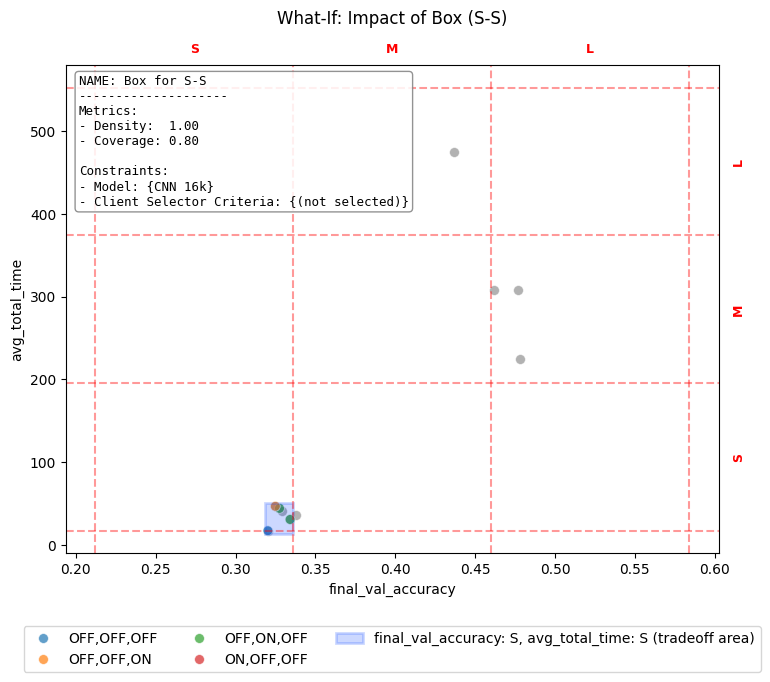

In [34]:
# Visualization of any example box
idx = 0
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    session.show_box_impact_objective_space(
        box=cart_box_list[idx],
        x_metric=x_col, 
        y_metric=y_col,
        tradeoff=session.get_tradeoff(tradeoffs[idx].name),
        show_box_summary=True,
        subset='test',
        cmap='tab10', 
        alpha=0.7,
        figsize=(8, 7),
        s=50
    )
    plt.show()

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


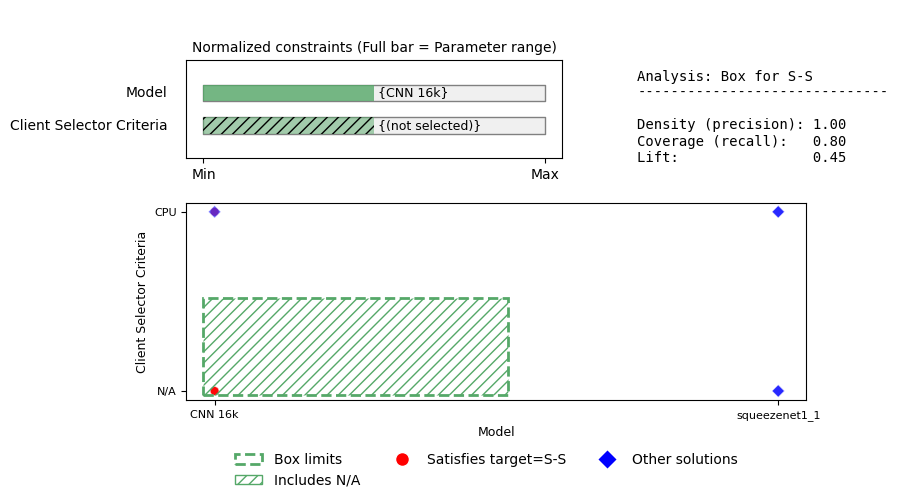

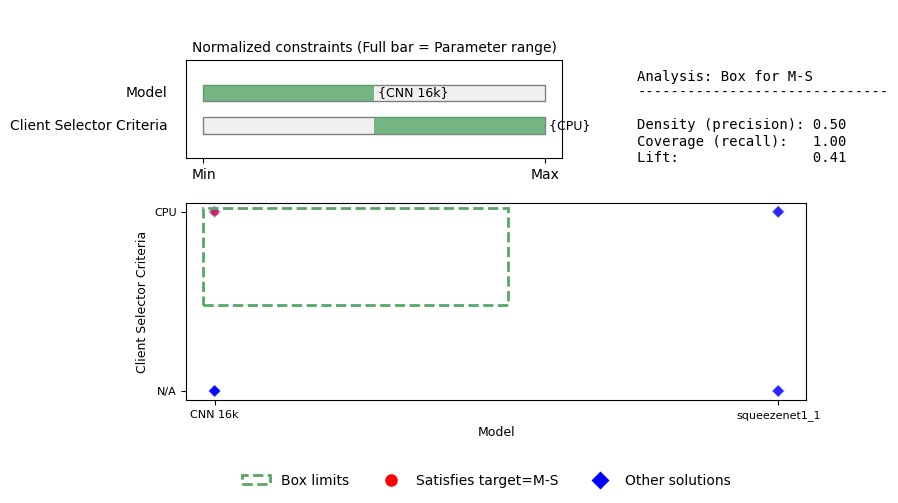

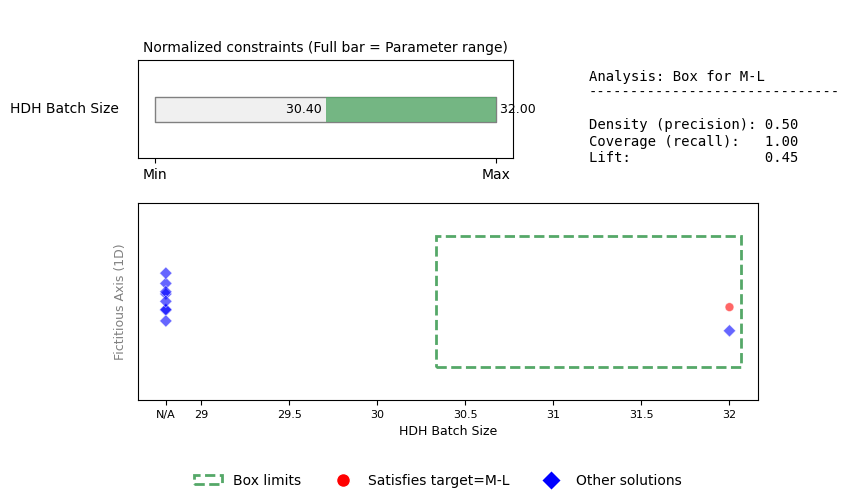

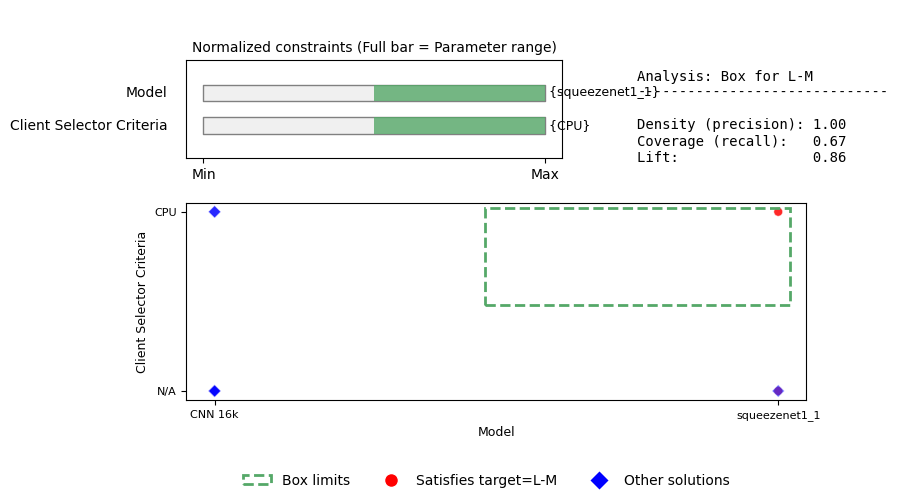

In [35]:
for box in prim_boxes: # Inspect PRIM boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=False, figsize=(8,5), title=" ") #, palette='tab10')
    fig.show()

## 11. Box Diagnostics (R9) and N/A-Hatching Check (R10)

We first visualize the first non-empty discovered box (PRIM or CART). We then
look for a box that also covers the "not selected" state of some optional
parameter (`box.includes_na`), which the diagnostics plot draws as a hatched
N/A region (R10).

For FL, a box covers the "not selected" state when it describes runs where a
pattern is OFF, e.g. a limit on `Client Selector Criteria` that includes its
"not selected" value. The cell below renders the first such box, or reports
explicitly that none was found.

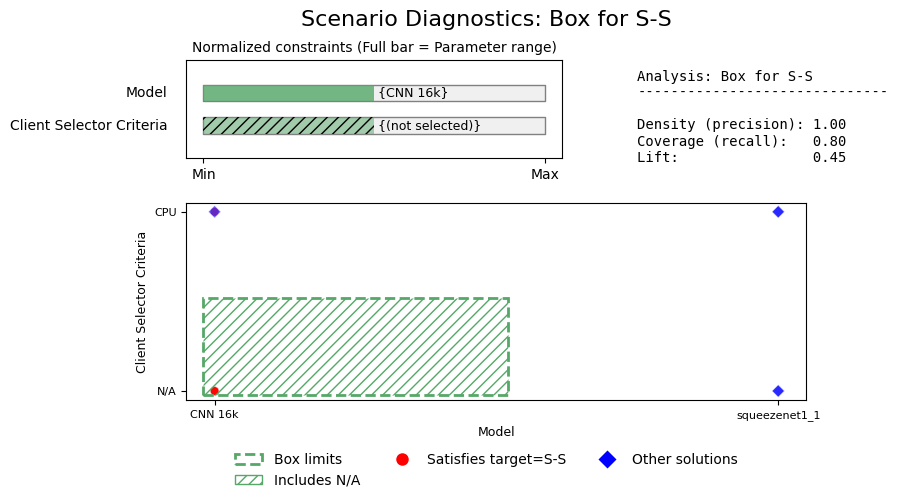

In [36]:
all_boxes = prim_boxes + cart_boxes

if all_boxes:
    first_box = all_boxes[0]
    fig = session.show_box_diagnostics(box=first_box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("No non-empty boxes were discovered by PRIM or CART; skipping box diagnostics.")

R10: box for S-S also covers 'Client Selector Criteria' = not selected: {'in': ['(not selected)'], 'includes_na': True}. Rendering N/A-hatching diagnostics:


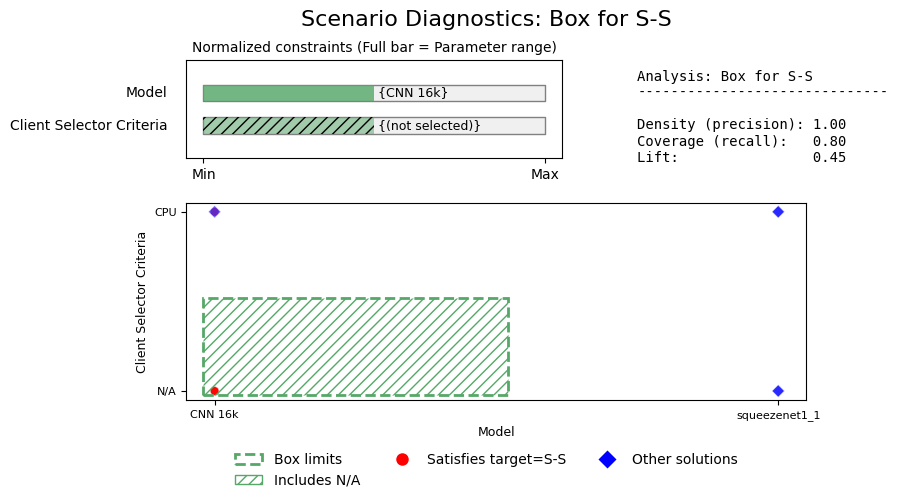

In [37]:
# Boxes record which optional parameters they cover in the "not selected" state
# (box.includes_na); readable_limits() marks those parameters with includes_na.
na_hatching_box = next(
    ((box, param) for box in all_boxes for param, covered in box.includes_na.items() if covered),
    None
)

if na_hatching_box:
    box, param_name = na_hatching_box
    print(f"R10: box for {box.target_tradeoff} also covers '{param_name}' = not selected: "
          f"{box.readable_limits()[param_name]}. Rendering N/A-hatching diagnostics:")
    fig = session.show_box_diagnostics(box=box, subset='test', show_policies=False, figsize=(8, 5))
    plt.show()
else:
    print("R10: no PRIM/CART box discovered in this run covers an optional parameter's "
          "'not selected' state, so there is no N/A region to hatch.")

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/390917906.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


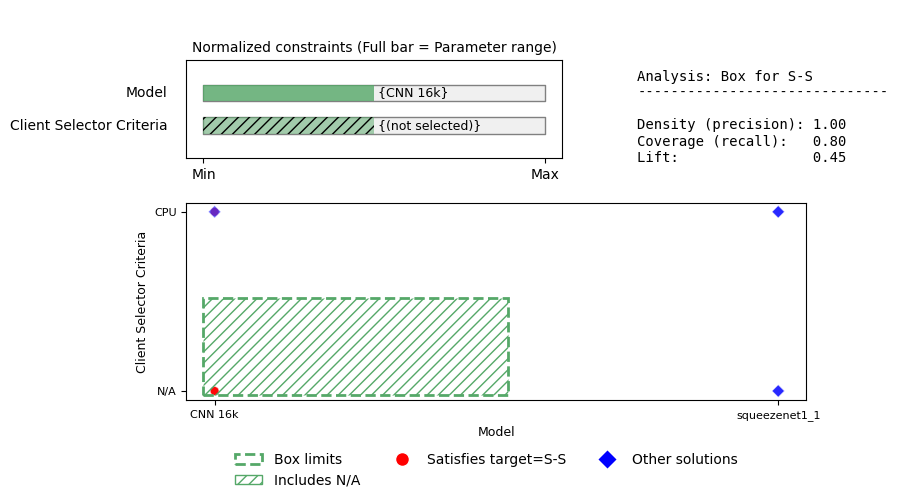

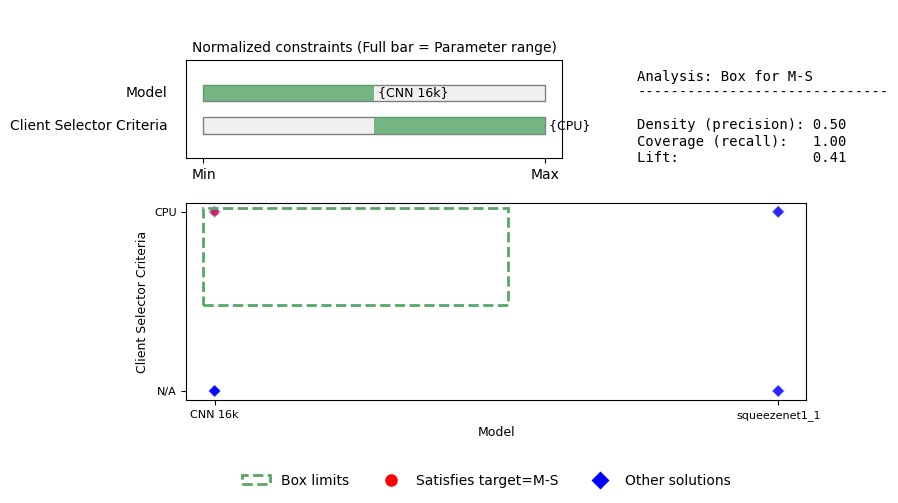

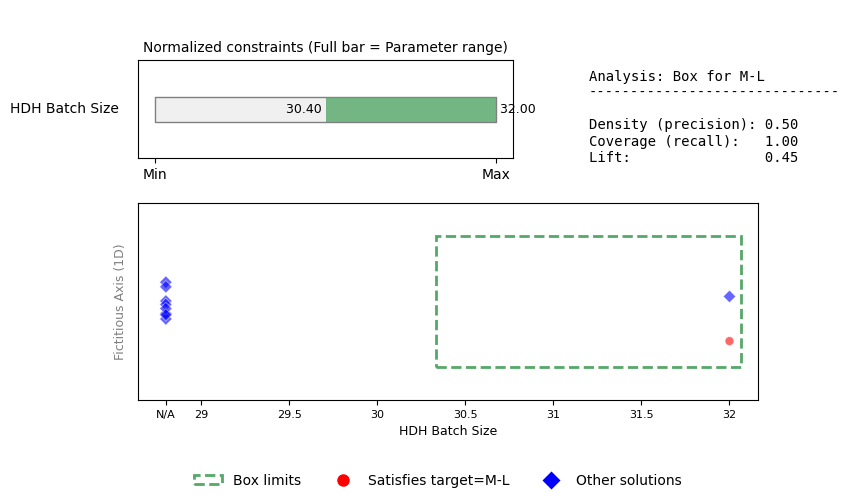

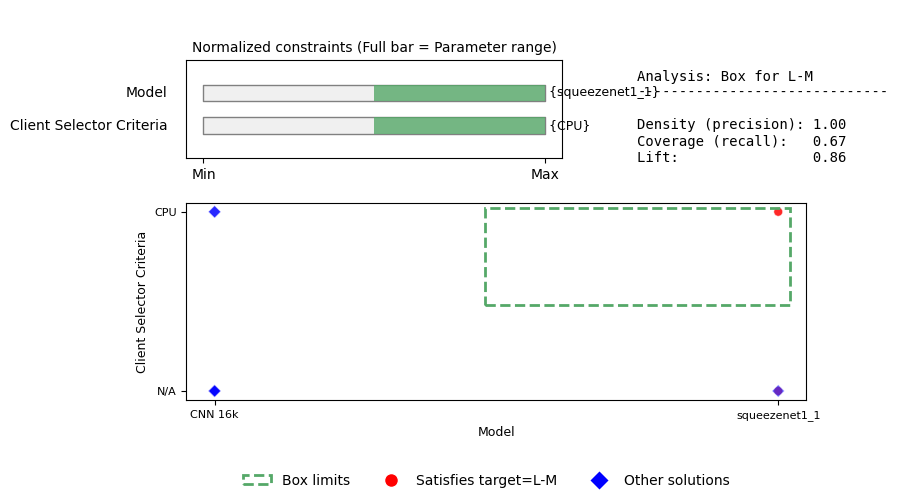

In [38]:
for box in prim_boxes: # Inspect PRIM boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=False, figsize=(8,5), title=" ") #, palette='tab10')
    fig.show()

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/534013300.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/534013300.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_70749/534013300.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


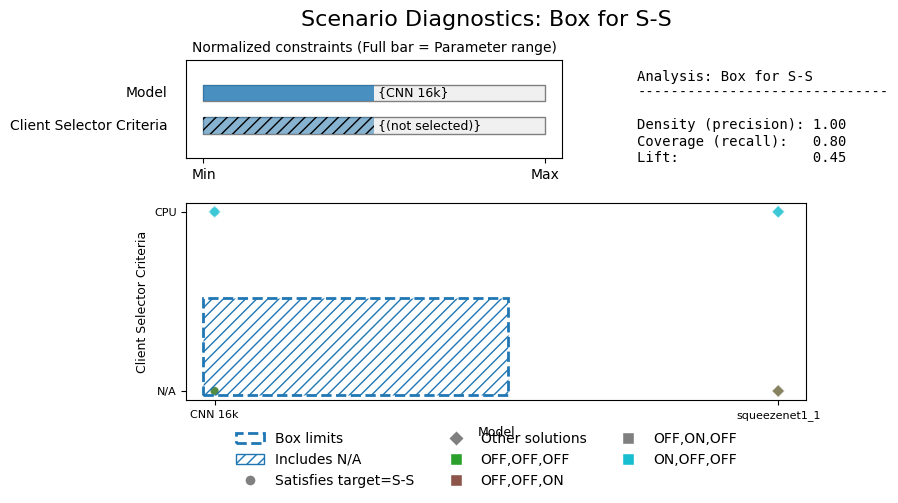

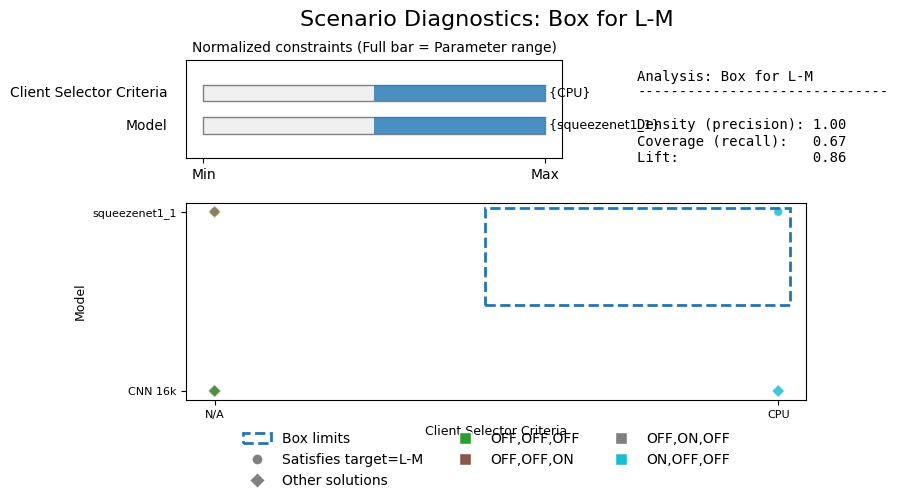

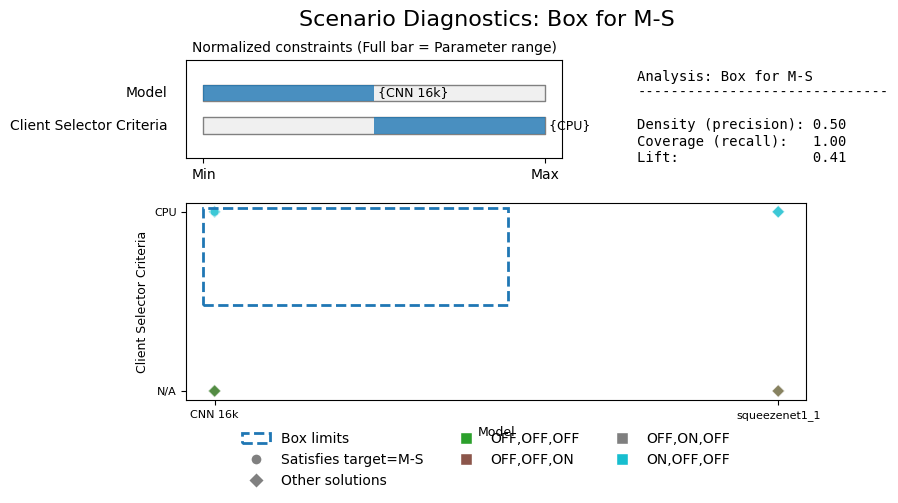

In [39]:
for box in cart_boxes: # Inspect CART boxes
    fig = session.show_box_diagnostics(box, subset='test', show_policies=True, figsize=(8,5)) #, palette='tab10')
    fig.show()

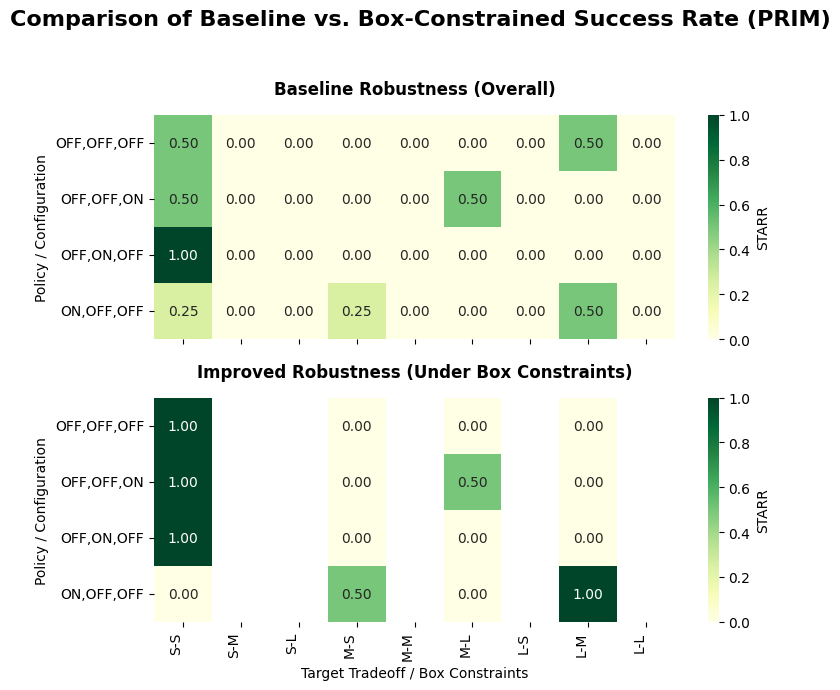

In [40]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

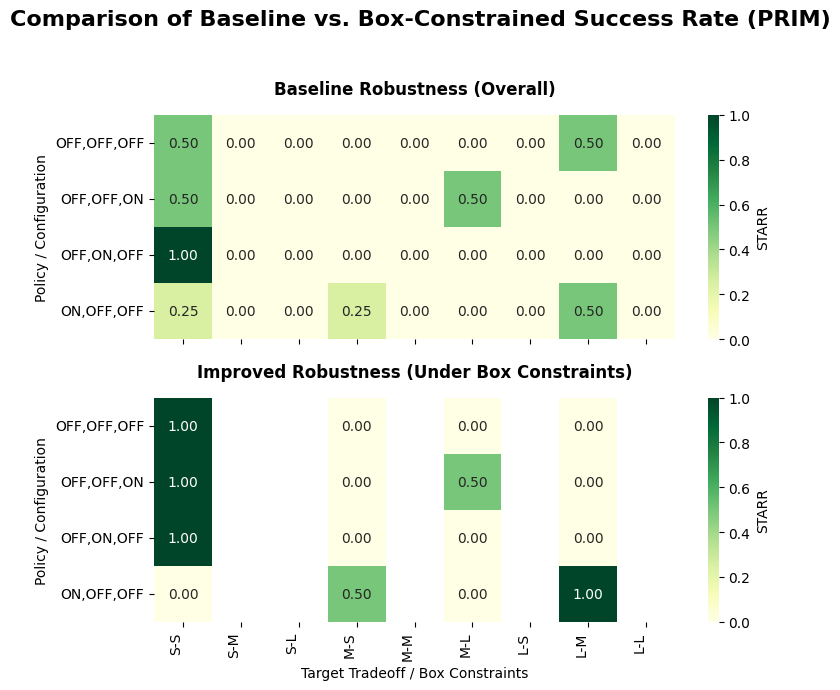

In [41]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

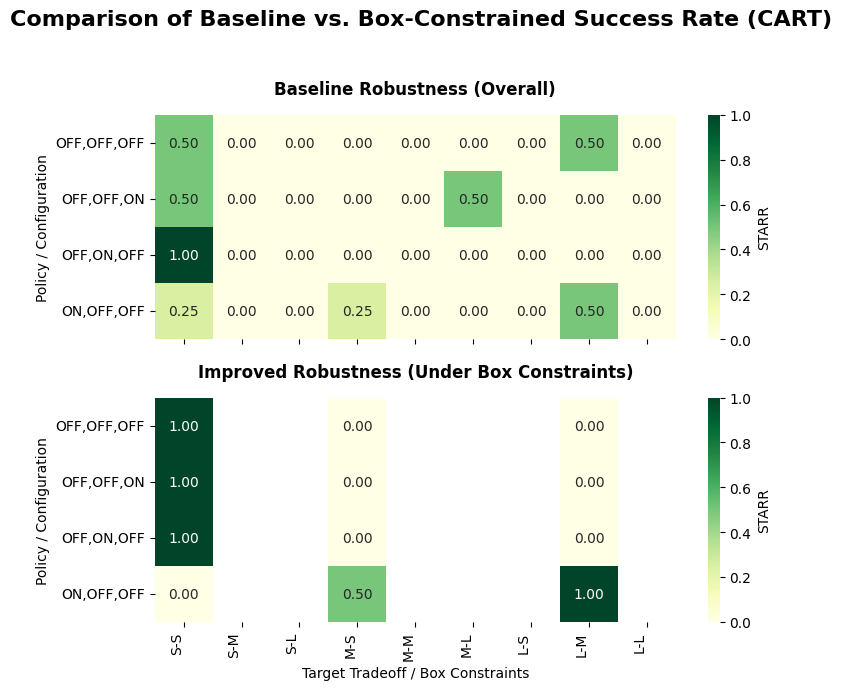

In [42]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=cart_robustness_improvement_matrix,
    boxes=cart_box_list, 
    metric=metric, 
    figsize=(8,7),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (CART)"
)

## 12. Performance Metrics

In [43]:
# PRIM
scores = session.get_algorithm_performance_scores(prim_boxes, return_std=True, subset='test')
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
prim_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df

4 tradeoffs to evaluate. 4 4


,metric,value
0,precision,0.750000
1,recall,0.866667
2,f1,0.755556
3,lift,0.500000
4,complexity,1.750000
5,success_rate,1.000000
6,precision_std,0.250000
7,recall_std,0.141421
8,f1_std,0.094281
9,lift_std,0.122474


In [44]:
# CART
scores = session.get_algorithm_performance_scores(cart_boxes, return_std=True, subset='test')
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
cart_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df


4 tradeoffs to evaluate. 3 3


,metric,value
0,precision,0.625000
1,recall,0.616667
2,f1,0.588889
3,lift,0.375000
4,complexity,2.000000
5,success_rate,0.750000
6,precision_std,0.414578
7,recall_std,0.375278
8,f1_std,0.349073
9,lift_std,0.294746


In [45]:
all_metrics = pd.concat([prim_df, cart_df], axis=0)
all_metrics.index = ['prim', 'cart']
# all_metrics.to_csv('metrics-fl.csv', decimal=',')
all_metrics

metric,precision,recall,f1,lift,complexity,success_rate,precision_std,recall_std,f1_std,lift_std,complexity_std
prim,0.75,0.866667,0.755556,0.5,1.75,1.0,0.25,0.141421,0.094281,0.122474,0.433013
cart,0.625,0.616667,0.588889,0.375,2.0,0.75,0.414578,0.375278,0.349073,0.294746,0.0


## 13. Notebook Status (R11)

This notebook is now the canonical validation path for the Federated Learning
example, exercising the framework's real methodology end to end: model
summary (R4), spec linting (R1-R3), tradeoff definition, per-decision
contingency analysis, key-parameter selection with FL's policy-bound pattern
parameters included (R6), PRIM/CART scenario discovery, and box diagnostics
including a best-effort N/A-hatching check (R9/R10).

`federatedlearning/test_manual_simple.py`, `federatedlearning/test_nan_feature.ipynb`,
and the root `test_nan_manual.py` are retired as the primary validation path
(R11). They remain in place -- unmodified, not deleted -- but should no
longer be treated as the authoritative way to validate FL support; use this
notebook instead.